# Doc2Vec
- Word2Vec의 확장판 모델
- 기본적인 매개변수, 속성, 메서드는 Word2Vec과 같다.
- 추가적인 부분이 생성

- 매개변수
    - dm
        - 기본값이 1
        - 학습 알고리즘을 선택
        - 1 : PV-DM
        - 0 : PT-DBOW
    - dm_mean
        - 기본값 : 0
        - PV-DM에서 문서 벡터의 계산 방식 
        - 0 : 벡터들의 합산 -> 범위가 커지는 경우가 발생 -> 노이즈로 인한 성능의 저하
        - 1 : 벡터들의 평균
    - dm_concat
        - 기본값 : 0
        - PV-DM에서 문석 벡터와 문장 벡터를 결합할 것인가?
        - 결합을 하는 경우 차원이 급격하게 증가
    - dbow-words
        - 기본값 : 0
        - PV-DBOW 사용 시 단어 벡터도 동시에 학습할 것인가? (Skip-gram 방식과 흡사)
- 속성
    - model.wv
        - 학습이 된 단어 벡터의 저장소
    - model.dv
        - 학습이 된 문장의 벡터의 저장소
    - model.dv.index_to_key
        - 문서들의 ID값 리스트
- 메서드
    - build_vocab()
        - 단어 / 문서 사진을 구성
    - train()
        - 사전이 구축이 된 뒤 직접 학습을 수행

- build_vocab(), train() 메서드를 이용하여 수동으로 학습을 설정 
- 일반적으로 Doc2Vec 객체를 생성할때 사전의 생성과 학습
- 증분 학습에서 사용이 되는 부분
    - 기존에 학습이 된 모델에 새로운 데이터셋을 추가
    - 데이터 양이 증가하면 성능이 오를수 있는 확률이 존재
    - 기존의 학습 시킨 데이터와 유사한 데이터를 증분학습하여 성능을 향상

In [38]:
# gensim 라이브러리 안에 Doc2Vec를 이용하여 임베딩
from konlpy.tag import Komoran
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import re


In [39]:
# 샘플 데이터를 2개의 유형 문장들로 구성
docs = [
    "나는 커피를 정말 좋아한다",
    "오늘 아침에 에스프레소 두 잔을 마셨다",
    "카페라떼가 제일 맛있다고 생각한다",
    "나는 차를 더 자주 마신다",
    "녹차를 마시면 기분이 편안해진다",
    "홍차는 향이 깊고 고급스러운 느낌이다",
    "카페에서 책을 읽는 시간이 너무 좋다",
    "허브티도 몸에 좋은거 같다"
]

In [40]:
# 형태소 분석 Komoran을 이용하여 토큰화
komoran = Komoran()

# 특정 품사만 사용
allow_pos = ['NNP', 'NNG', 'VV','VA', 'MAG']
# 불용어
stop_word = ['하다', '되다', '이것', '것', '수', '거']

# 문자에서 불필요한 글자들을 제거 (정규화)
def nomalize(text):
    # 특수문자 제외, 공백에 대한 처리
    text = re.sub(r"[^가-힝0-9a-zA-Z\s\.]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# 토큰화 함수를 정의
def tokenize(text):
    # 문자의 정규화 함수를 호출
    text = nomalize(text)
    
    tokens = []
    for word, pos in komoran.pos(text):
        if pos in allow_pos:
            # 길이를 체크하기 전에 동사, 형용사 에는 '다' 붙이기 활용
            if pos in ['VV', 'VA']:
                word += '다'
            if word not in stop_word and len(word) > 1:
                # allow_pos에 포함되어있고
                # stop_word에 포함되어있지 않으며
                # 단어의 길이가 1보다 큰 문자만 활용
                tokens.append(word)
    return tokens

In [41]:
tokenize_docs = [tokenize(doc) for doc in docs]
tokenize_docs

[['커피', '정말', '좋아하다'],
 ['오늘', '아침', '에스프레소', '마시다'],
 ['카페', '제일', '맛있다', '생각'],
 ['자주', '마시다'],
 ['녹차', '마시다', '기분', '편안'],
 ['홍차', '깊다', '고급', '느낌'],
 ['카페', '읽다', '시간', '너무', '좋다'],
 ['허브', '좋다', '같다']]

In [42]:
# 문장 별로 ID를 지정
tagged = []
for idx, toks in enumerate(tokenize_docs):
    # TaggedIocument를 이용하여 문장 당 ID를 부여하고 tagged에 추가
    tagged.append(
        TaggedDocument(words = toks, tags = [f"DOC_{idx}"])
    )
tagged

[TaggedDocument(words=['커피', '정말', '좋아하다'], tags=['DOC_0']),
 TaggedDocument(words=['오늘', '아침', '에스프레소', '마시다'], tags=['DOC_1']),
 TaggedDocument(words=['카페', '제일', '맛있다', '생각'], tags=['DOC_2']),
 TaggedDocument(words=['자주', '마시다'], tags=['DOC_3']),
 TaggedDocument(words=['녹차', '마시다', '기분', '편안'], tags=['DOC_4']),
 TaggedDocument(words=['홍차', '깊다', '고급', '느낌'], tags=['DOC_5']),
 TaggedDocument(words=['카페', '읽다', '시간', '너무', '좋다'], tags=['DOC_6']),
 TaggedDocument(words=['허브', '좋다', '같다'], tags=['DOC_7'])]

In [43]:
# tag를 추가한 문서를 이용해서 Doc2Vec 모델에 학습 데이터로 이용
model = Doc2Vec(
    documents=tagged,
    vector_size=120,
    window= 5,
    min_count = 1,      # 데이터의 개수가 작기 때문, 실제 3-5
    dm=1,               # PV-DM 방식
    dm_mean=1,          # 벡터들의 평균(범위를 크지 않게 잡아서 안정적)
    negative= 5,        # 잘못된 단어간의 배치를 사용하여 학습에 이용
    epochs=50,          
    seed=42
)

In [44]:
print("학습이 된 문장의 개수", len(model.dv))

학습이 된 문장의 개수 8


In [52]:
# 문장 간의 유사도를 수치적으로 확인
def print_similities(doc_id):
    dic_vec = model.dv[f"DOC_{doc_id}"]
    # doc_id : 문서의 tag 이름
    # 각각의 문장들의 벡터 데이터를 리스트로 생성
    mat = np.vstack(
        [model.dv[f"DOC_{i}"] for i in range(len(docs))]
    )
    
    # 코사인 유사도 사용
    sims = cosine_similarity([dic_vec], mat)[0]
    order = sims.argsort()[::-1]
    print(f"기존의 문장 : {doc_id} -> {docs[doc_id]}")
    for idx in order:
        print(f"    -> {idx} {docs[idx]}   |  cos = {sims[idx]}")
        
print_similities(0)

기존의 문장 : 0 -> 나는 커피를 정말 좋아한다
    -> 0 나는 커피를 정말 좋아한다   |  cos = 1.0
    -> 7 허브티도 몸에 좋은거 같다   |  cos = 0.1954648792743683
    -> 1 오늘 아침에 에스프레소 두 잔을 마셨다   |  cos = 0.13140203058719635
    -> 3 나는 차를 더 자주 마신다   |  cos = 0.06367944180965424
    -> 6 카페에서 책을 읽는 시간이 너무 좋다   |  cos = 0.01677805185317993
    -> 4 녹차를 마시면 기분이 편안해진다   |  cos = 0.007417656481266022
    -> 2 카페라떼가 제일 맛있다고 생각한다   |  cos = -0.06176169961690903
    -> 5 홍차는 향이 깊고 고급스러운 느낌이다   |  cos = -0.11510717123746872


In [53]:
# 차원 축소 기법을 이용해서 그래프 시각화
# 각 문장들 간에 거리를 확인
from sklearn.manifold import TSNE

In [55]:
# 차원 축소를 하기 위해서는 -> 고차원의 데이터 필요
X = np.vstack(
    [model.dv[f"DOC_{idx}"] for idx in range(len(docs))]
)
X.shape

(8, 120)

In [56]:
# t-SNE를 이용하여 2D 변경
tsne = TSNE(
    n_components=2,
    perplexity=5,
    max_iter=2000,
    random_state=42
)

In [57]:
# 차원 축소 모델에 학습을 시키고 데이터를 변형한다.
X_2d = tsne.fit_transform(X)

In [58]:
X_2d.shape

(8, 2)

In [59]:
import matplotlib.pyplot as plt

In [66]:
# 그래프는 산점도 그래프
# 각각의 점에 주석 -> 해당 위치의 문장데이터
# 문당들이 한글 -> 기본적인 matplot 폰트에서는 한글 지원X -> 폰트를 변경
# 각각의 os에 따라서 폰트 설정이 다름
import platform

if platform.system() == 'Darwin':
    plt.rc('font', family ='AppleGothic')
else:
    plt.rc('font', family='Malgun Gothic')
    
# 마이너스 부호 깨짐의 방지
plt.rcParams['axes.unicode_minus'] = False

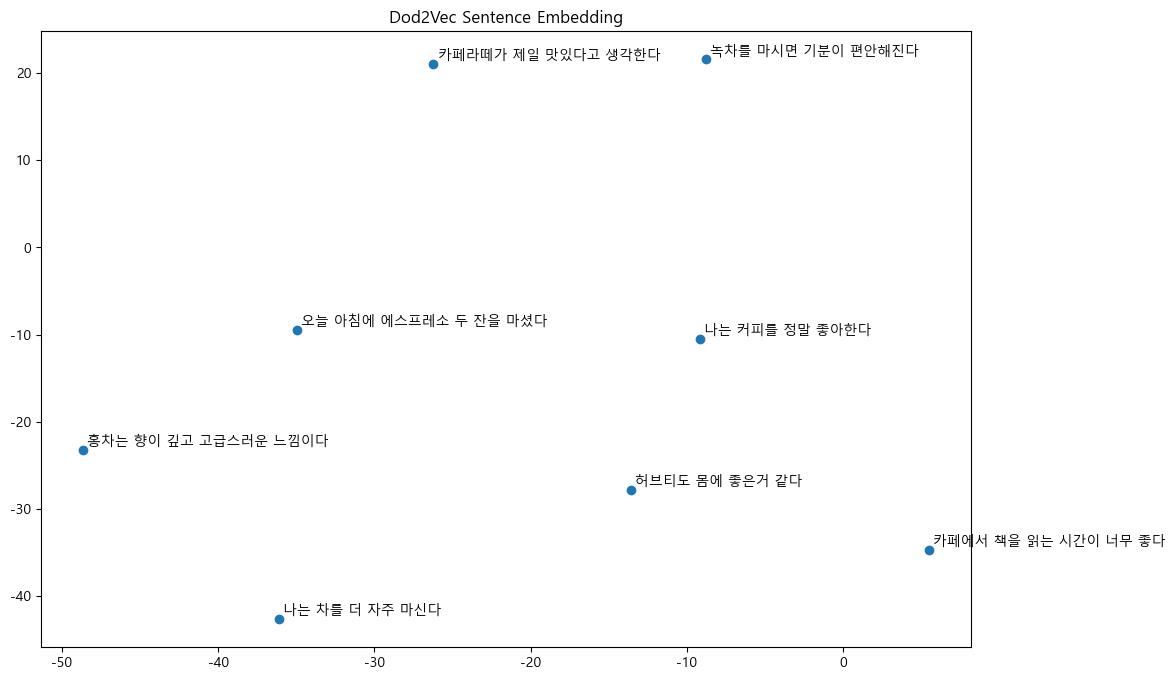

In [67]:
plt.figure(figsize=(12, 8))
# 산점도 그래프를 생성 -> X축 데이터, Y축 데이터 -> X_2d의 첫벌째 열과 두번째 열
plt.scatter(X_2d[:, 0], X_2d[:, 1])

# 각가의 점들에 문장 데이터를 주석으로 추가
for idx, text in enumerate(docs):
    plt.annotate(
        text,
        # 주석의 원 데이터의 위치
        xy= (X_2d[idx, 0], X_2d[idx, 1]),
        # 주석의 위치
        xytext=(3, 3),
        textcoords='offset points '     # 각각의 위치에 텍스트 대입
    )

plt.title('Dod2Vec Sentence Embedding')
plt.show()